# 📊 Telco Customer Churn Analysis

## Business Problem

A telecommunications company is experiencing customer churn and wants to understand why customers are leaving. The objective is to analyze customer behavior, identify the key factors associated with churn, and build a machine learning model capable of predicting whether a customer is likely to leave the company.

---

## Project Objectives

- Understand the dataset and each feature.
- Identify data quality issues.
- Explore customer churn patterns.
- Perform feature engineering.
- Build and evaluate predictive models.
- Provide business recommendations to improve customer retention.

## Import Required Libraries

In this section, we import the libraries required for data manipulation, numerical computations, and visualization throughout the project.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Improve plot appearance
plt.style.use("ggplot")

## Load the Dataset

The dataset is loaded from the **data** directory. This dataset contains customer demographic information, services subscribed, account details, and whether the customer churned.

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Observations

The dataset has been loaded successfully. The first five records provide an initial understanding of customer information, subscribed services, billing details, and the target variable (`Churn`).

## Dataset Shape

The shape of the dataset tells us the total number of rows (observations) and columns (features). This helps us understand the size of the dataset before analysis.

In [5]:
print("Dataset Shape:", df.shape)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Dataset Shape: (7043, 21)

Number of Rows    : 7043
Number of Columns : 21


## Dataset Information

The `info()` method provides a quick overview of the dataset, including column names, data types, number of non-null values, and memory usage. This helps identify potential data quality issues such as missing values and incorrect data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## First and Last Five Records

Displaying both the first and last five records helps verify that the dataset has been loaded correctly and provides an initial understanding of the available data.

In [7]:
print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Last 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Column Names

Listing all column names provides an overview of the available features and helps us understand what information is available for analysis.

In [8]:
print("Total Columns:", len(df.columns))
print()

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Total Columns: 21

1. customerID
2. gender
3. SeniorCitizen
4. Partner
5. Dependents
6. tenure
7. PhoneService
8. MultipleLines
9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


## Observations

- The dataset contains **7,043 customer records**.
- There are **21 columns**, including customer information, subscribed services, billing details, and the target variable (`Churn`).
- The dataset size is sufficient for performing exploratory data analysis and building a machine learning model.

## Observations

- The dataset contains **7,043 observations** and **21 features**.
- Based on `df.info()`, there are **18 categorical features**, **2 integer features**, and **1 floating-point feature**.
- No missing values are detected based on non-null counts.
- However, the **TotalCharges** column has the `object` data type even though it represents monetary values. This suggests that the column may contain invalid or blank entries and should be investigated during data cleaning.

## Missing Values

Checking for missing values helps identify incomplete records that may affect data analysis and model performance.

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate Records

Duplicate records can introduce bias into the analysis and should be identified before model development.

In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Missing Values

Missing values can negatively affect data analysis and machine learning models. In this section, we check whether any columns contain missing values.

In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## Duplicate Records

Duplicate records can introduce bias into the analysis. Therefore, we check whether duplicate customer records exist in the dataset.

In [13]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


## Statistical Summary

The statistical summary provides descriptive statistics for the numerical variables, helping us understand their distribution, central tendency, and spread.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [16]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Observations

- No explicit missing values were detected using `isnull()`.
- All 21 columns contain complete records.
- However, this does not necessarily mean the dataset is completely clean.
- Some datasets use blank strings (`""`) or whitespace (`" "`) instead of `NaN`, which will be investigated during the data cleaning phase.

### Observations

- No duplicate customer records were found.
- Each row appears to represent a unique customer.

### Observations

- Only three numerical variables are currently recognized.
- `TotalCharges` is missing from the numerical summary because it is stored as an object instead of a numeric data type.
- This indicates that the column requires further investigation during the data cleaning phase.

## Key Findings

- The dataset contains **7,043 customer records** and **21 features**.
- No explicit missing values were detected.
- No duplicate records were found.
- Most variables are categorical.
- `TotalCharges` is stored as an object instead of a numeric data type and requires further investigation.
- The target variable (`Churn`) appears to be imbalanced, with "No" occurring more frequently than "Yes".

## Target Variable Analysis

The target variable is **Churn**, which indicates whether a customer has left the company. Understanding its distribution helps determine whether the dataset is balanced and provides insight into the business problem.

In [17]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


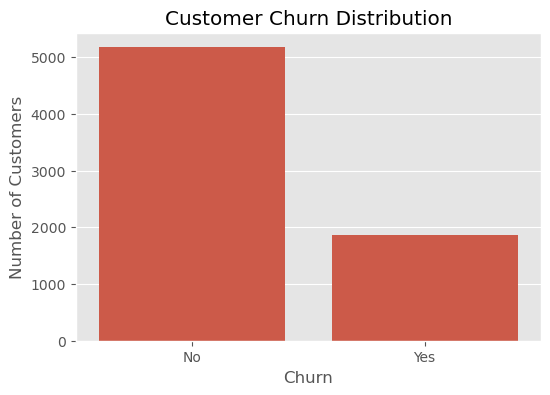

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

- The majority of customers belong to one class.
- This indicates that the target variable is not perfectly balanced.
- Class imbalance should be considered during model evaluation.
- Appropriate evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC may be more informative than accuracy alone.

# Data Cleaning

## Objective

The purpose of this phase is to identify and resolve data quality issues before performing exploratory data analysis and machine learning. A clean dataset improves the reliability of insights and model performance.

## Inspecting the `TotalCharges` Column

During the data understanding phase, we observed that the `TotalCharges` column is stored as an `object` data type, even though it represents monetary values. This section investigates the reason behind this issue.

In [20]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [21]:
df["TotalCharges"].dtype

dtype('O')

In [22]:
# Check for blank or whitespace values
blank_values = (df["TotalCharges"].str.strip() == "").sum()

print(f"Blank values in TotalCharges: {blank_values}")

Blank values in TotalCharges: 11


## Technical Observation

- The `TotalCharges` column is stored as an `object` instead of a numeric data type.
- Investigation revealed **11 blank (whitespace) values** in the column.
- These blank values are not detected by `isnull()` because they are empty strings rather than actual `NaN` values.
- The presence of these blank values prevents pandas from automatically recognizing the column as numeric.

## Business Interpretation

`TotalCharges` represents the total amount a customer has paid to the company. Since this is a financial variable, it must be stored as a numeric data type.

If left uncorrected, this issue would prevent numerical analysis, correlation calculations, visualizations, and machine learning models from using this important feature correctly.

## Replacing Blank Values

Blank strings in the `TotalCharges` column are replaced with `NaN` so that they can be handled as missing values in later steps.

In [23]:
import numpy as np

# Replace blank strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [29]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [28]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [26]:
df["TotalCharges"].dtype

dtype('float64')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Technical Observation

- The `TotalCharges` column was successfully converted from `object` to `float64`.
- A total of **11 blank values** were identified and converted into missing (`NaN`) values.
- After conversion, the column contains **7032 valid numeric values** and **11 missing values**.
- The dataset is now ready for proper missing value handling.

## Business Interpretation

The `TotalCharges` feature represents the total amount paid by a customer over their relationship with the company.

Converting this feature to a numeric format allows it to be used in:
- Statistical analysis
- Correlation analysis
- Data visualization
- Machine learning models

Without this correction, valuable customer billing information would not be available for predictive analysis.

## Handling Missing Values

The `TotalCharges` column contains only **11 missing values**, representing approximately **0.16%** of the dataset.

Since this is a very small proportion and these records correspond to customers without valid total charges, these rows will be removed instead of imputing artificial values.

In [30]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

In [31]:
print(df.shape)

print(df.isnull().sum().sum())

(7032, 21)
0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7032, 21)


In [34]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [35]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Key Observations

- Converted `TotalCharges` from `object` to `float64`.
- Identified and removed 11 records with missing `TotalCharges`.
- The cleaned dataset contains **7032 records**.
- No missing values or duplicate records remain.
- The dataset is now ready for Exploratory Data Analysis.

In [37]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [38]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df = df.dropna(subset=["TotalCharges"])

# Exploratory Data Analysis (EDA)

## Business Question 1

What proportion of customers churned, and is the dataset balanced?

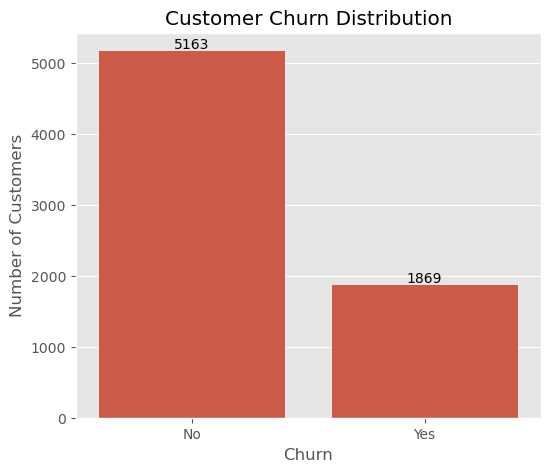

In [39]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [40]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


### Key Findings

- The dataset contains 7,032 customers after data cleaning.
- 5,163 customers (73.42%) did not churn.
- 1,869 customers (26.58%) churned.
- The target variable is moderately imbalanced, with non-churn customers forming the majority.

### Business Insight

Approximately one in every four customers has churned, indicating that customer attrition is a significant business concern. Since the classes are moderately imbalanced, model evaluation should rely on metrics such as Precision, Recall, F1-score, and ROC-AUC rather than accuracy alone.

## Business Question 2

How are the numerical features distributed, and do they contain potential outliers?

We analyze the numerical features to understand their distribution, spread, and identify any unusual values that may affect the model.

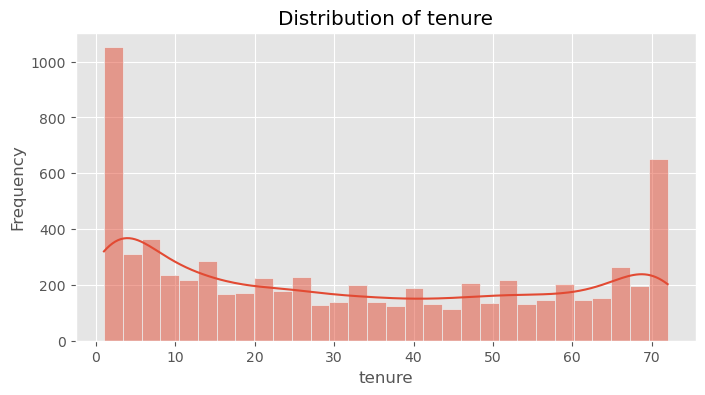

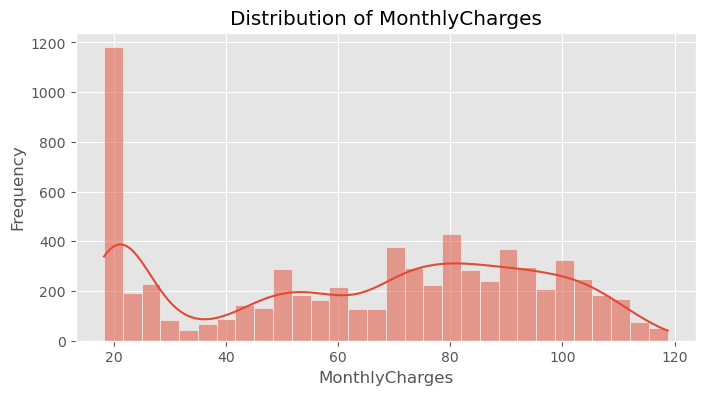

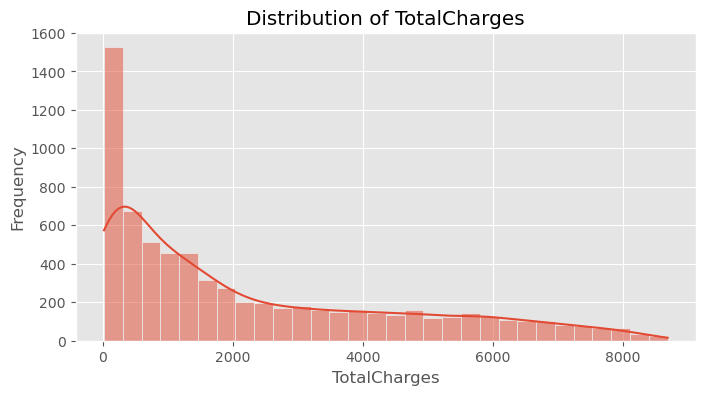

In [41]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(df[feature], bins=30, kde=True)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

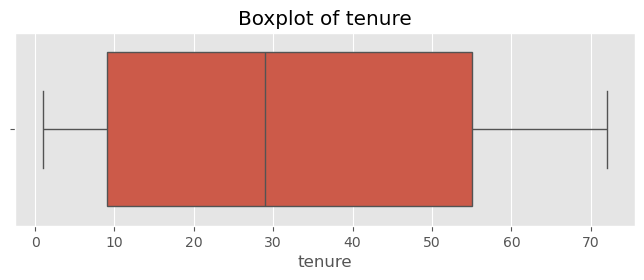

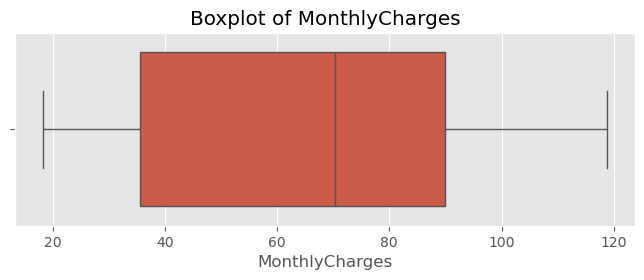

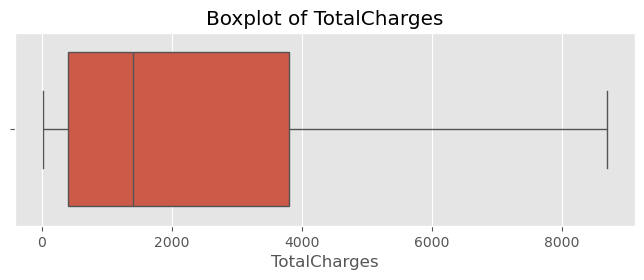

In [42]:
for feature in numerical_features:
    plt.figure(figsize=(8, 2.5))

    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")

    plt.show()

In [43]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [44]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].skew()

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64

In [45]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


### Key Findings

- The average customer tenure is **32.42 months**, with customer subscriptions ranging from **1 to 72 months**.
- The average monthly charge is **64.80**, while total charges average **2283.30**.
- `TotalCharges` shows a positive skew (**0.96**), indicating that most customers have lower total charges while a smaller group of long-term customers have much higher total charges.
- `tenure` and `MonthlyCharges` are only slightly skewed, suggesting relatively balanced distributions.
- No outliers were detected in any numerical feature using the IQR method.

### Business Insight

The numerical features appear clean and well-behaved, making them suitable for predictive modeling. The positive skew in `TotalCharges` is expected because long-term customers naturally accumulate higher charges over time. Since no significant outliers were detected, no outlier treatment is required at this stage.

## Business Question 3

Does customer gender influence churn?

We first examine the distribution of customers by gender and then compare churn rates across both groups.

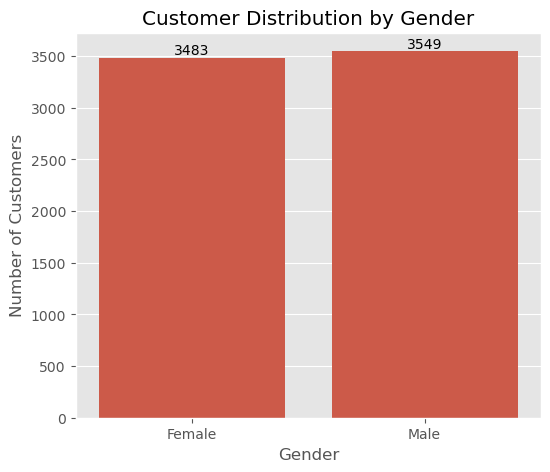

In [46]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="gender")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [47]:
gender_percentage = (
    df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(gender_percentage)

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64


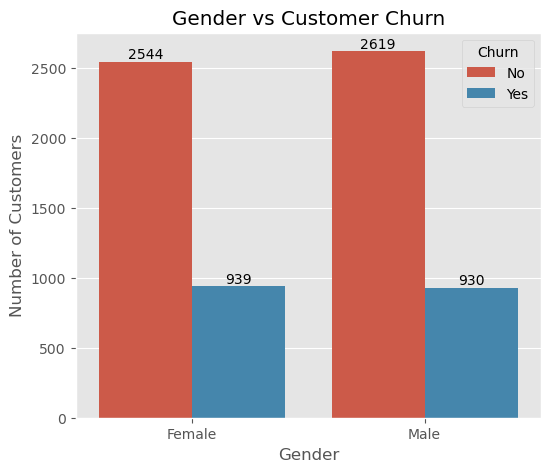

In [48]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

plt.show()

In [49]:
gender_churn = (
    pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
).round(2)

print(gender_churn)

Churn      No    Yes
gender              
Female  73.04  26.96
Male    73.80  26.20


### Key Findings

- The customer base is almost evenly distributed by gender.
- Male customers represent **50.47%** of the dataset, while female customers represent **49.53%**.
- The churn rate for female customers is **26.96%**.
- The churn rate for male customers is **26.20%**.
- The difference in churn rates is less than **1%**, indicating very similar behavior across genders.

### Business Insight

Gender does not appear to have a significant influence on customer churn. Both male and female customers leave the company at nearly the same rate. Therefore, gender is unlikely to be a strong predictor of churn, and customer retention strategies should focus on other factors such as contract type, tenure, internet service, and monthly charges.

## Business Question 4

Are senior citizens more likely to churn than non-senior customers?

This analysis compares the churn behavior of senior citizens and non-senior customers to determine whether age group is associated with customer retention.

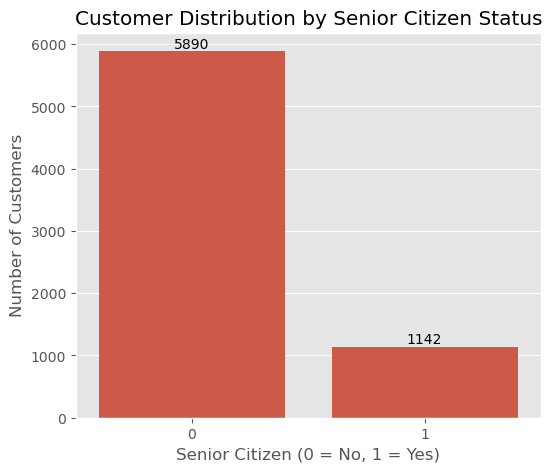

In [50]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="SeniorCitizen")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [51]:
senior_percentage = (
    df["SeniorCitizen"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(senior_percentage)

SeniorCitizen
0    83.76
1    16.24
Name: proportion, dtype: float64


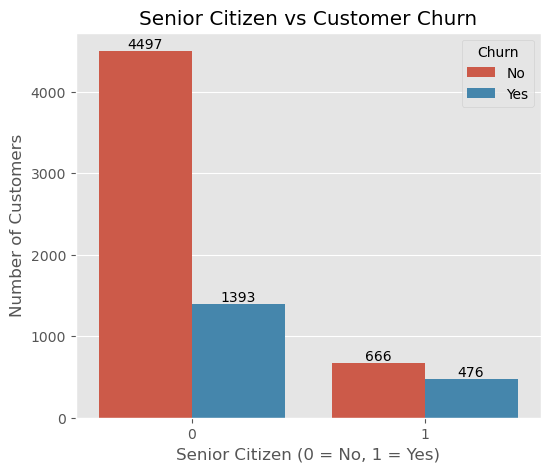

In [52]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

plt.show()

In [53]:
senior_churn = (
    pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
).round(2)

print(senior_churn)

Churn             No    Yes
SeniorCitizen              
0              76.35  23.65
1              58.32  41.68


### Key Findings

- Senior citizens make up **16.24%** of the customer base, while **83.76%** are non-senior customers.
- The churn rate among senior citizens is **41.68%**.
- The churn rate among non-senior customers is **23.65%**.
- Senior citizens churn at a substantially higher rate than non-senior customers.
- This indicates a strong relationship between senior citizen status and customer churn.

### Business Insight

Senior citizens are considerably more likely to leave the company's services than non-senior customers. This suggests that older customers may face challenges related to pricing, service complexity, or customer support. The company should consider targeted retention strategies such as dedicated customer support, simplified service plans, or loyalty incentives for senior customers.

### Decision

The `SeniorCitizen` feature will be retained for model development because it shows a strong relationship with customer churn and is likely to be an important predictive feature.

## Business Question 3

Does the customer's contract type influence churn?

This analysis examines whether customers on different contract plans have different churn rates.

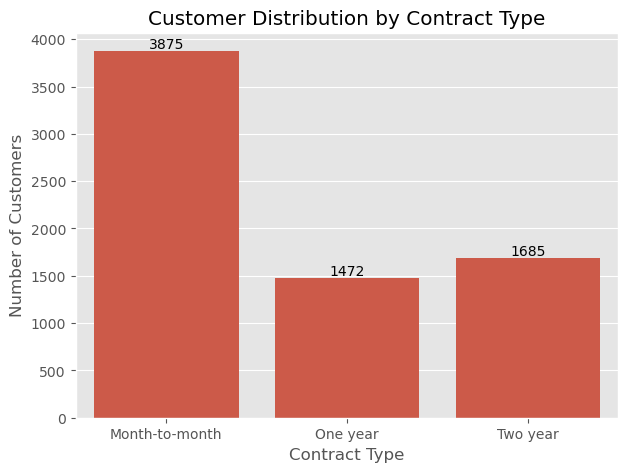

In [54]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="Contract")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

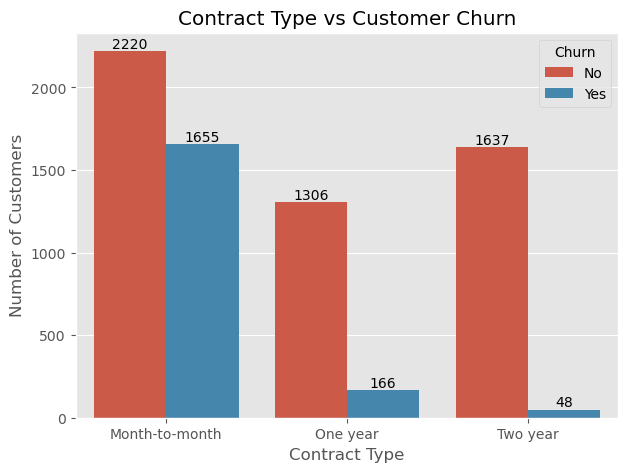

In [55]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

plt.show()

In [56]:
contract_churn = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
).round(2)

print(contract_churn)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


### Key Findings

- Customers with **month-to-month contracts** have the highest churn rate (**42.71%**).
- Customers with a **one-year contract** have a much lower churn rate (**11.28%**).
- Customers with a **two-year contract** have the lowest churn rate (**2.85%**).
- Longer contract durations are strongly associated with lower customer churn.

### Business Insight

Contract type is one of the strongest factors influencing customer churn. Customers on month-to-month contracts are significantly more likely to leave the company, while customers on longer-term contracts show much higher loyalty. The company should encourage customers to switch from month-to-month plans to annual or two-year contracts through discounts or loyalty incentives.

### Decision

The `Contract` feature will be retained because it has a strong relationship with customer churn and is expected to be one of the most important predictors in the machine learning model.

## Business Question 4

Does the type of internet service influence customer churn?

This analysis examines whether customers using different internet service types have different churn rates.

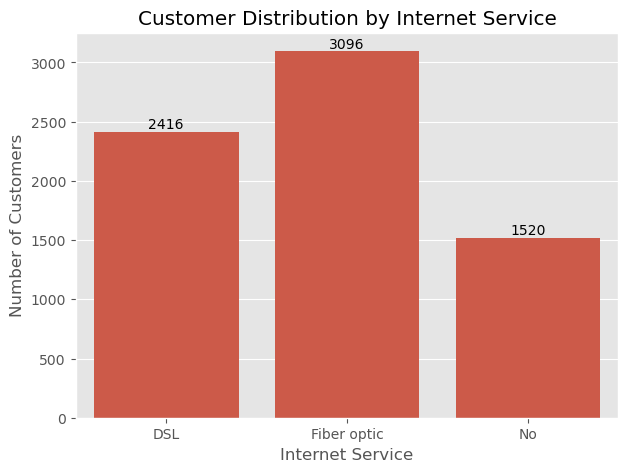

In [57]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="InternetService")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

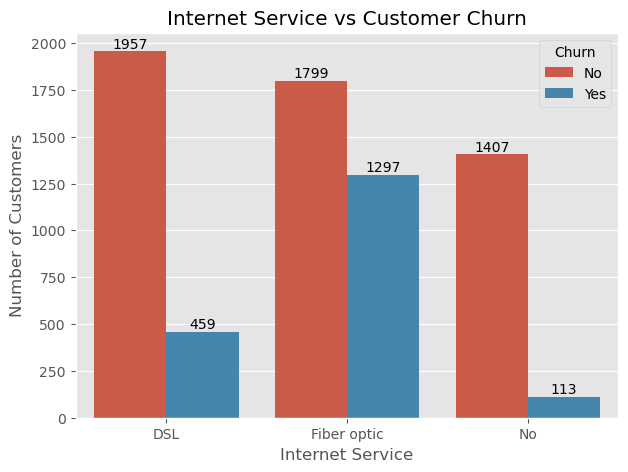

In [58]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

plt.show()

In [59]:
internet_churn = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
).round(2)

print(internet_churn)

Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


### Key Findings

- Customers using **Fiber Optic** internet have the highest churn rate (**41.89%**).
- Customers using **DSL** have a much lower churn rate (**19.00%**).
- Customers with **No Internet Service** have the lowest churn rate (**7.43%**).
- Fiber Optic customers are significantly more likely to churn than customers using other internet services.

### Business Insight

Internet service type has a strong relationship with customer churn. Customers using Fiber Optic services leave the company at a much higher rate than DSL or customers without internet service. This may indicate issues related to pricing, service quality, or customer expectations. The company should investigate customer satisfaction among Fiber Optic users and introduce targeted retention strategies.

### Decision

The `InternetService` feature will be retained because it has a strong association with customer churn and is expected to contribute significantly to the prediction model.

## Business Question 5

Does customer tenure influence customer churn?

This analysis examines whether customers with shorter or longer tenures are more likely to churn.

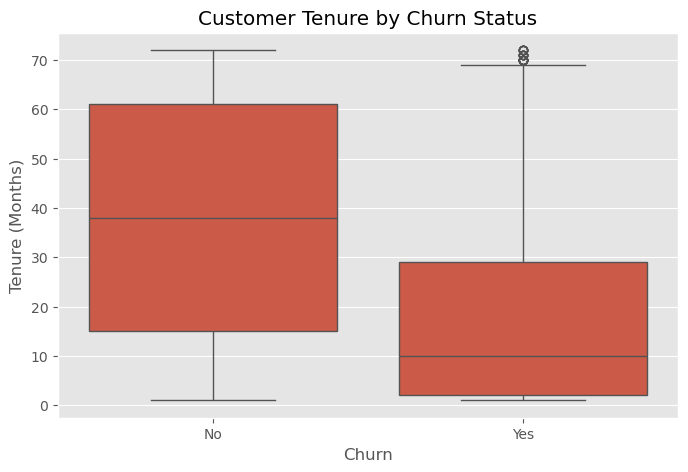

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Key Findings

- Customers who churn generally have a much shorter tenure than customers who remain with the company.
- Non-churn customers have a higher median tenure.
- The tenure of non-churn customers is more widely distributed, indicating many long-term loyal customers.
- Customer tenure is strongly associated with churn.

### Business Insight

Customers who have recently joined the company are more likely to churn, while long-term customers tend to remain loyal. This suggests that the company should focus on improving customer experience and engagement during the early months of the customer lifecycle.

### Decision

The `tenure` feature will be retained because it has a strong relationship with customer churn and is expected to be an important predictor in the machine learning model.